In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content
!wget -q --no-check-certificate https://www.crcv.ucf.edu/data/UCF101/UCF101TrainTestSplits-RecognitionTask.zip
!unzip -q UCF101TrainTestSplits-RecognitionTask.zip
!ls /content/ucfTrainTestlist

/content
classInd.txt	testlist02.txt	trainlist01.txt  trainlist03.txt
testlist01.txt	testlist03.txt	trainlist02.txt


In [3]:
import os

%cd /content
!git clone https://github.com/miirage-exe/video-action-recognition.git
%cd video-action-recognition

/content
Cloning into 'video-action-recognition'...
remote: Enumerating objects: 161, done.
remote: Total 161 (delta 0), reused 0 (delta 0), pack-reused 161 (from 2)
Receiving objects: 100% (161/161), 306.66 MiB | 32.40 MiB/s, done.
Resolving deltas: 100% (57/57), done.
Updating files: 100% (61/61), done.
/content/video-action-recognition


In [4]:
# Step 1: Library Import
from pathlib import Path
from collections import Counter, defaultdict
import re, random

import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from tqdm import tqdm

# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

import os

# Paths: env vars allow Docker reuse; Colab defaults preserved
DATA_DIR  = Path(os.environ.get("DATA_DIR",  "/content/drive/MyDrive/datasets/UCF-101"))
SPLIT_DIR = Path(os.environ.get("SPLIT_DIR", "/content/ucfTrainTestlist"))
OUT_DIR   = Path(os.environ.get("OUT_DIR",   "outputs_40_epochs_with_augmented"))
OUT_DIR.mkdir(parents=True, exist_ok=True)

# hyperparameters
NUM_FRAMES = 8
IMAGE_SIZE = 112
BATCH_SIZE = 16
NUM_EPOCHS = 40
LEARNING_RATE = 1e-3
SPLIT_ID = 1
VAL_RATIO = 0.2

Using: cuda
GPU: Tesla T4


In [5]:
# Step 2: Data Directory
class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"Number of classes: {len(class_names)}")
print(f"First 5 Classes: {class_names[:5]}")

video_files = list(DATA_DIR.rglob("*.avi"))
print(f"Number of video files: {len(video_files)}")

Number of classes: 101
First 5 Classes: ['ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam']
Number of video files: 13320


Number of classes: 101
First 5 Classes: ['ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam']
Number of video files: 13320
Sample video: /content/drive/MyDrive/datasets/UCF-101/CuttingInKitchen/v_CuttingInKitchen_g01_c01.avi
frame count, fps, width, height: 301, 25.0, 320, 240


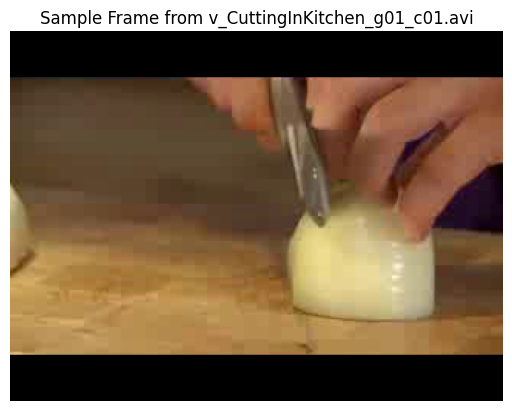

In [6]:
# Step 3 Document understanding + visualization
class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"Number of classes: {len(class_names)}")
print(f"First 5 Classes: {class_names[:5]}")

video_files = list(DATA_DIR.rglob("*.avi"))
print(f"Number of video files: {len(video_files)}")

sample_video_path = video_files[0]
cap = cv2.VideoCapture(str(sample_video_path))

if not cap.isOpened():
    raise IOError(f"Cannot open video file: {sample_video_path}")

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps         = cap.get(cv2.CAP_PROP_FPS)
width       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Sample video: {sample_video_path}")
print(f"frame count, fps, width, height: {frame_count}, {fps}, {width}, {height}")

success, frame = cap.read()
if success:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.title(f"Sample Frame from {sample_video_path.name}")
    plt.show()
cap.release()

In [7]:
# Step 4: Modeling Configuration and Manifest
NUM_FRAMES    = 8
IMAGE_SIZE    = 112
BATCH_SIZE    = 16    # GPU version hyperparameters
NUM_EPOCHS    = 40    # GPU version hyperparameters
LEARNING_RATE = 1e-3
SPLIT_ID      = 1
VAL_RATIO     = 0.2

NUM_SELECTED_CLASSES = len(class_names)
selected_classes     = class_names[:NUM_SELECTED_CLASSES]
NUM_SELECTED_CLASSES = len(selected_classes)

print(f"Number of classes used for training: {NUM_SELECTED_CLASSES}")
print(f"Class preview: {selected_classes[:min(10, NUM_SELECTED_CLASSES)]}")

def build_manifest_from_split(split_dir, data_dir, selected_classes, method):
    if method == "train":
        split_file = split_dir / f"trainlist{SPLIT_ID:02d}.txt"
    elif method == "test":
        split_file = split_dir / f"testlist{SPLIT_ID:02d}.txt"
    else:
        raise ValueError("method must be 'train' or 'test'")

    if not split_file.exists():
        raise FileNotFoundError(f"Split file not found: {split_file}")

    selected_set   = set(selected_classes)
    class_to_label = {c: i for i, c in enumerate(selected_classes)}
    manifest = []

    with open(split_file, "r") as f:
        for line in f:
            relative_path = line.strip().split()[0]
            class_name    = relative_path.split("/")[0]
            if class_name not in selected_set:
                continue
            full_video_path = data_dir / relative_path
            label = class_to_label[class_name]
            if full_video_path.exists():
                manifest.append((full_video_path, label, class_name))
            else:
                print(f"Warning: Video file not found: {full_video_path}")

    return manifest

train_files = build_manifest_from_split(SPLIT_DIR, DATA_DIR, selected_classes, method="train")
test_files  = build_manifest_from_split(SPLIT_DIR, DATA_DIR, selected_classes, method="test")

print(f"Train manifest videos: {len(train_files)}")
print(f"Test manifest videos:  {len(test_files)}")
print(f"First train entry: {train_files[0]}")
print(f"First test entry:  {test_files[0]}")

Number of classes used for training: 101
Class preview: ['ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam', 'BandMarching', 'BaseballPitch', 'Basketball', 'BasketballDunk', 'BenchPress']
Train manifest videos: 9537
Test manifest videos:  3783
First train entry: (PosixPath('/content/drive/MyDrive/datasets/UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g08_c01.avi'), 0, 'ApplyEyeMakeup')
First test entry:  (PosixPath('/content/drive/MyDrive/datasets/UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c01.avi'), 0, 'ApplyEyeMakeup')


In [8]:
# Step 5: Train/Val Split
def extract_group_id(video_path):
    match = re.search(r'g\d+', Path(video_path).name)
    return match.group(0) if match else None

def split_train_val_by_group(train_files, val_ratio, seed):
    # Group videos by (class_name, group_id)
    grouped_videos = defaultdict(list)
    for video in train_files:
        video_path, label, class_name = video
        group_id = extract_group_id(video_path)
        group_key = (class_name, group_id)
        grouped_videos[group_key].append(video)

    # Collect group keys per class
    class_to_groups = defaultdict(list)
    for class_name, group_id in grouped_videos.keys():
        class_to_groups[class_name].append((class_name, group_id))

    rng = random.Random(seed)
    val_group_keys = set()

    # Apply val_ratio independently within each class so every class
    # contributes roughly the same fraction of groups to validation.
    for class_name, group_keys in class_to_groups.items():
        rng.shuffle(group_keys)
        num_val = max(1, int(len(group_keys) * val_ratio))
        for key in group_keys[:num_val]:
            val_group_keys.add(key)

    train_set, val_set = [], []
    for group_key, videos in grouped_videos.items():
        if group_key in val_group_keys:
            val_set.extend(videos)
        else:
            train_set.extend(videos)

    return train_set, val_set

train_set, val_set = split_train_val_by_group(train_files, VAL_RATIO, seed=42)
print(f"Train: {len(train_set)} videos")
print(f"Val:   {len(val_set)} videos")
print(f"Test:  {len(test_files)} videos")

Train: 7950 videos
Val:   1587 videos
Test:  3783 videos


Sample count by split:
     train: 7950 videos
validation: 1587 videos
      test: 3783 videos

Class distribution summary:
Classes: 101
Minimum videos per class: 100
Maximum videos per class: 167
Mean videos per class: 131.88
Median videos per class: 131.00

Classes with smallest and largest sample counts:
class_name                        train      val     test    total
------------------------------------------------------------------
Skijet                               60       12       28      100
TaiChi                               60       12       28      100
PullUps                              60       12       28      100
PlayingViolin                        60       12       28      100
BreastStroke                         61       12       28      101
PushUps                              60       12       30      102
UnevenBars                           64       12       28      104
PlayingPiano                         63       14       28      105
BalanceBeam          

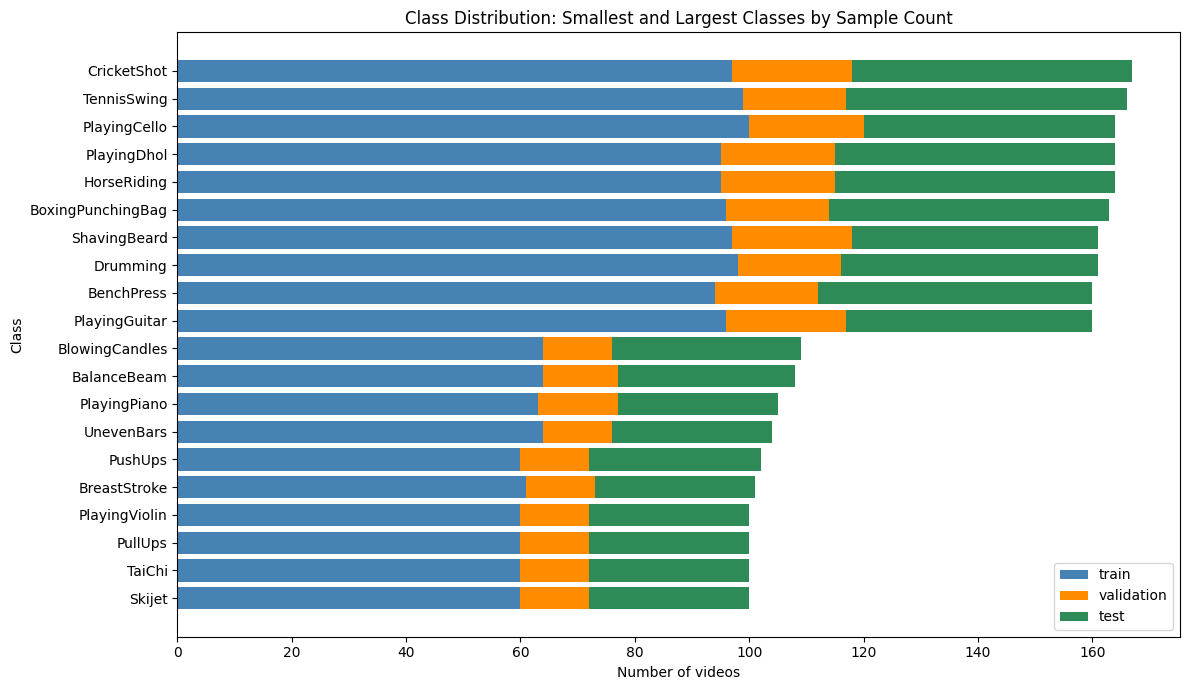

In [9]:
# Step 6: Analyze Data Split

def count_by_class(samples):
    """Count the number of videos for each class in a split."""
    return Counter(class_name for _, _, class_name in samples)


def groups_by_split(samples):
    """Return class-level group keys to check leakage between splits."""
    group_keys = set()
    for video_path, _, class_name in samples:
        group_id = extract_group_id(video_path)
        group_keys.add((class_name, group_id))
    return group_keys


def select_extreme_indices(values, top_k):
    """Return unique indices from the low and high ends of a sorted array."""
    sorted_indices = np.argsort(values)
    candidate_indices = np.concatenate([sorted_indices[:top_k], sorted_indices[-top_k:]])
    return np.array(list(dict.fromkeys(candidate_indices.tolist())))


def print_distribution_table(indices, class_names, distribution_matrix):
    header = f"{'class_name':<30} {'train':>8} {'val':>8} {'test':>8} {'total':>8}"
    print(header)
    print("-" * len(header))
    for idx in indices:
        train_count = distribution_matrix[0, idx]
        val_count = distribution_matrix[1, idx]
        test_count = distribution_matrix[2, idx]
        total_count = train_count + val_count + test_count
        print(f"{class_names[idx]:<30} {train_count:>8} {val_count:>8} {test_count:>8} {total_count:>8}")


split_samples = {
    "train": train_set,
    "validation": val_set,
    "test": test_files,
}

print("Sample count by split:")
for split_name, samples in split_samples.items():
    print(f"{split_name:>10}: {len(samples)} videos")

class_distribution = {
    split_name: count_by_class(samples)
    for split_name, samples in split_samples.items()
}

distribution_matrix = np.array([
    [class_distribution["train"].get(class_name, 0) for class_name in selected_classes],
    [class_distribution["validation"].get(class_name, 0) for class_name in selected_classes],
    [class_distribution["test"].get(class_name, 0) for class_name in selected_classes],
])

total_counts = distribution_matrix.sum(axis=0)
summary_indices = select_extreme_indices(total_counts, top_k=min(10, len(selected_classes)))

print("\nClass distribution summary:")
print(f"Classes: {len(selected_classes)}")
print(f"Minimum videos per class: {total_counts.min()}")
print(f"Maximum videos per class: {total_counts.max()}")
print(f"Mean videos per class: {total_counts.mean():.2f}")
print(f"Median videos per class: {np.median(total_counts):.2f}")
print("\nClasses with smallest and largest sample counts:")
print_distribution_table(summary_indices, selected_classes, distribution_matrix)

print("\nMissing classes by split:")
for split_name, distribution in class_distribution.items():
    missing_classes = [
        class_name
        for class_name in selected_classes
        if distribution.get(class_name, 0) == 0
    ]
    print(f"{split_name:>10}: {missing_classes if missing_classes else 'none'}")

print("\nGroup overlap check:")
group_sets = {
    split_name: groups_by_split(samples)
    for split_name, samples in split_samples.items()
}

overlap_pairs = [
    ("train", "validation"),
    ("train", "test"),
    ("validation", "test"),
]

for left, right in overlap_pairs:
    overlap = group_sets[left] & group_sets[right]
    if overlap:
        print(f"WARNING: {left} / {right} overlap: {len(overlap)} class-group pairs")
        print(sorted(overlap)[:10])
    else:
        print(f"{left:>10} / {right:<10}: no group overlap")

plot_indices = summary_indices
plot_classes = [selected_classes[i] for i in plot_indices]
plot_train = distribution_matrix[0, plot_indices]
plot_val = distribution_matrix[1, plot_indices]
plot_test = distribution_matrix[2, plot_indices]

y = np.arange(len(plot_classes))
plt.figure(figsize=(12, max(6, len(plot_classes) * 0.35)))
plt.barh(y, plot_train, label="train", color="steelblue")
plt.barh(y, plot_val, left=plot_train, label="validation", color="darkorange")
plt.barh(y, plot_test, left=plot_train + plot_val, label="test", color="seagreen")
plt.yticks(y, plot_classes)
plt.xlabel("Number of videos")
plt.ylabel("Class")
plt.title("Class Distribution: Smallest and Largest Classes by Sample Count")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Step 7: Video Loading
def load_video_clip(video_path, num_frames, img_size):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise IOError(f"Cannot open video file: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames < num_frames:
        raise ValueError(f"Video has only {total_frames} frames.")

    frame_indices = np.linspace(0, total_frames-1, num_frames, dtype=int)
    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        success, frame = cap.read()
        if not success:
            if frames:
                frames.append(frames[-1].copy())
            continue
        frame_rgb     = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame_resized = cv2.resize(frame_rgb, (img_size, img_size))
        frame         = frame_resized.astype(np.float32) / 255.0
        frames.append(frame)

    cap.release()
    if len(frames) == 0:
        raise ValueError(f"Could not read any frames from: {video_path}")
    while len(frames) < num_frames:
        frames.append(frames[-1].copy())

    clip = np.stack(frames, axis=0)
    clip = np.transpose(clip, (3, 0, 1, 2))
    return torch.from_numpy(clip)

sample_clip = load_video_clip(train_set[0][0], NUM_FRAMES, IMAGE_SIZE)
print(f"Clip shape: {sample_clip.shape}")

Clip shape: torch.Size([3, 8, 112, 112])


In [11]:
# Step 8: Dataset & DataLoader
class VideoDataSet(Dataset):
    def __init__(self, samples, num_frames, img_size):
        self.samples = samples
        self.num_frames = num_frames
        self.img_size = img_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label, class_name = self.samples[idx]
        clip = load_video_clip(video_path, self.num_frames, self.img_size)
        label = torch.tensor(label, dtype=torch.long)
        return clip, label, str(video_path), class_name

train_dataset = VideoDataSet(train_set, NUM_FRAMES, IMAGE_SIZE)
val_dataset   = VideoDataSet(val_set,   NUM_FRAMES, IMAGE_SIZE)
test_dataset  = VideoDataSet(test_files, NUM_FRAMES, IMAGE_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# verify
clips, labels, _, _ = next(iter(train_loader))
print(f"Batch shape: {clips.shape}")
print(f"Labels shape: {labels.shape}")

Batch shape: torch.Size([16, 3, 8, 112, 112])
Labels shape: torch.Size([16])


aug_train_loader :  7950 clips  (497 batches)


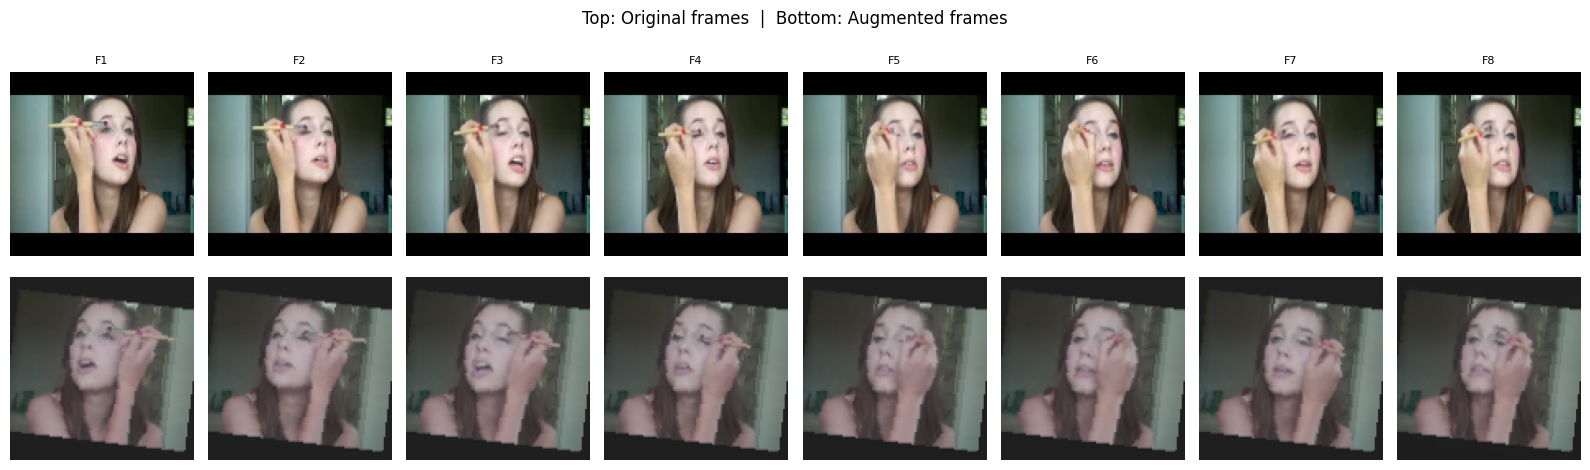

Original clip  — min: 0.000  max: 0.996
Augmented clip — min: 0.117  max: 0.746


In [12]:
# Step 8b: Data Augmentation for Frame-level CNN (anti-overfitting)
# The Frame-level CNN strongly overfits (train ~96 % vs val ~40 %).
# Strategy: apply a set of consistent spatial + colour augmentations so that
# every frame in the same clip undergoes the *same* random transformation.
# Temporal coherence is preserved — there is no visible "jump" between frames.
# Val / test loaders are kept clean (no augmentation).

import torchvision.transforms as transforms
import torchvision.transforms.functional as TF


class FrameAugmenter:
    """
    Samples one set of random parameters per clip and applies them identically
    to every frame, preserving temporal coherence.

    Augmentations included
    ──────────────────────
    • RandomResizedCrop  — random zoom-in / crop  (scale 70-100 %)
    • RandomHorizontalFlip
    • RandomRotation     — ±15°
    • ColorJitter        — brightness, contrast, saturation, hue
    • RandomGrayscale    — 10 % of clips converted to greyscale (3-ch kept)
    • GaussianBlur       — 20 % of clips lightly blurred
    """

    def __init__(
        self,
        img_size: int = 112,
        scale: tuple = (0.70, 1.0),
        ratio: tuple = (0.75, 1.33),
        hflip_p: float = 0.5,
        rotation_deg: float = 15.0,
        brightness: float = 0.4,
        contrast: float = 0.4,
        saturation: float = 0.3,
        hue: float = 0.1,
        grayscale_p: float = 0.10,
        blur_p: float = 0.20,
    ):
        self.img_size = img_size
        self.scale = scale
        self.ratio = ratio
        self.hflip_p = hflip_p
        self.rotation_deg = rotation_deg
        self.brightness = brightness
        self.contrast = contrast
        self.saturation = saturation
        self.hue = hue
        self.grayscale_p = grayscale_p
        self.blur_p = blur_p

    def __call__(self, clip: torch.Tensor) -> torch.Tensor:
        """
        Args:
            clip: FloatTensor  (C, T, H, W)  values in [0, 1]
        Returns:
            Augmented FloatTensor  (C, T, H, W)
        """
        C, T, H, W = clip.shape

        # ── Sample one set of random parameters for the whole clip ────────────

        # 1. RandomResizedCrop — use the first frame as shape reference
        top, left, crop_h, crop_w = transforms.RandomResizedCrop.get_params(
            clip[:, 0],          # (C, H, W) — only shape matters
            scale=self.scale,
            ratio=self.ratio,
        )

        # 2. Horizontal flip
        do_hflip = random.random() < self.hflip_p

        # 3. Rotation angle
        angle = random.uniform(-self.rotation_deg, self.rotation_deg)

        # 4. ColorJitter parameters (fn_idx encodes the application order)
        fn_idx, brightness_f, contrast_f, saturation_f, hue_f = \
            transforms.ColorJitter.get_params(
                brightness=(max(0.0, 1 - self.brightness), 1 + self.brightness),
                contrast  =(max(0.0, 1 - self.contrast),   1 + self.contrast),
                saturation=(max(0.0, 1 - self.saturation), 1 + self.saturation),
                hue       =(-self.hue, self.hue),
            )

        # 5. Grayscale / blur decisions
        do_grayscale = random.random() < self.grayscale_p
        do_blur      = random.random() < self.blur_p
        blur_kernel  = random.choice([3, 5])          # odd kernel sizes only

        # ── Apply the same parameters to every frame in the clip ─────────────
        augmented = []
        for t in range(T):
            frame = clip[:, t, :, :]                  # (C, H, W)

            # Crop + resize (zoom)
            frame = TF.resized_crop(
                frame, top, left, crop_h, crop_w,
                size=[self.img_size, self.img_size],
            )

            # Flip
            if do_hflip:
                frame = TF.hflip(frame)

            # Rotation
            frame = TF.rotate(frame, angle)

            # Colour jitter (order randomised by fn_idx each clip)
            for fn_id in fn_idx:
                if fn_id == 0:
                    frame = TF.adjust_brightness(frame, brightness_f)
                elif fn_id == 1:
                    frame = TF.adjust_contrast(frame, contrast_f)
                elif fn_id == 2:
                    frame = TF.adjust_saturation(frame, saturation_f)
                elif fn_id == 3:
                    frame = TF.adjust_hue(frame, hue_f)

            # Grayscale (keep 3 channels so the CNN architecture is unchanged)
            if do_grayscale:
                frame = TF.rgb_to_grayscale(frame, num_output_channels=3)

            # Gaussian blur
            if do_blur:
                frame = TF.gaussian_blur(frame, kernel_size=blur_kernel)

            augmented.append(frame)

        return torch.stack(augmented, dim=1)           # (C, T, H, W)


class AugmentedVideoDataSet(Dataset):
    """Drop-in replacement for VideoDataSet with optional training augmentation."""

    def __init__(self, samples, num_frames: int, img_size: int, augment: bool = False):
        self.samples    = samples
        self.num_frames = num_frames
        self.img_size   = img_size
        self.augmenter  = FrameAugmenter(img_size=img_size) if augment else None

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label, class_name = self.samples[idx]
        clip = load_video_clip(video_path, self.num_frames, self.img_size)  # (C, T, H, W)
        if self.augmenter is not None:
            clip = self.augmenter(clip)
        return clip, torch.tensor(label, dtype=torch.long), str(video_path), class_name


# ── Rebuild data loaders — augmentation ON for training, OFF for val/test ─────
aug_train_dataset = AugmentedVideoDataSet(train_set,   NUM_FRAMES, IMAGE_SIZE, augment=True)
aug_val_dataset   = AugmentedVideoDataSet(val_set,     NUM_FRAMES, IMAGE_SIZE, augment=False)
aug_test_dataset  = AugmentedVideoDataSet(test_files,  NUM_FRAMES, IMAGE_SIZE, augment=False)

aug_train_loader = DataLoader(aug_train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)

print(f"aug_train_loader : {len(aug_train_dataset):>5} clips  ({len(aug_train_loader)} batches)")

# ── Sanity-check visualisation: one clip before vs after augmentation ─────────
_sample_clip_orig = load_video_clip(train_set[0][0], NUM_FRAMES, IMAGE_SIZE)
_augmenter        = FrameAugmenter(img_size=IMAGE_SIZE)
_sample_clip_aug  = _augmenter(_sample_clip_orig.clone())

fig, axes = plt.subplots(2, NUM_FRAMES, figsize=(2 * NUM_FRAMES, 5))
fig.suptitle("Top: Original frames  |  Bottom: Augmented frames", fontsize=12)
for t in range(NUM_FRAMES):
    orig = _sample_clip_orig[:, t].permute(1, 2, 0).numpy()
    aug  = _sample_clip_aug[:,  t].permute(1, 2, 0).clamp(0, 1).numpy()
    axes[0, t].imshow(orig); axes[0, t].axis("off"); axes[0, t].set_title(f"F{t+1}", fontsize=8)
    axes[1, t].imshow(aug);  axes[1, t].axis("off")
plt.tight_layout()
plt.show()

print(f"Original clip  — min: {_sample_clip_orig.min():.3f}  max: {_sample_clip_orig.max():.3f}")
print(f"Augmented clip — min: {_sample_clip_aug.min():.3f}  max: {_sample_clip_aug.max():.3f}")


In [13]:
train_loader = aug_train_loader

In [14]:
# Step 9: Frame-level CNN Model
class FrameLevelCNN(nn.Module):
    def __init__(self, num_classes):
        super(FrameLevelCNN, self).__init__()
        self.cnn = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.cnn.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(self.cnn.fc.in_features, num_classes)
        )

    def forward(self, x):
        batch_size, channels, num_frames, height, width = x.shape
        x = x.permute(0, 2, 1, 3, 4)
        x = x.reshape(batch_size * num_frames, channels, height, width)
        frame_outputs = self.cnn(x)
        frame_outputs = frame_outputs.reshape(batch_size, num_frames, -1)
        video_outputs = frame_outputs.mean(dim=1)
        return video_outputs

model = FrameLevelCNN(num_classes=NUM_SELECTED_CLASSES).to(device)

# verify
clips, labels, _, _ = next(iter(train_loader))
outputs = model(clips.to(device))
print(f"Input shape:  {clips.shape}")
print(f"Output shape: {outputs.shape}")
print(f"Device: {next(model.parameters()).device}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 120MB/s]


Input shape:  torch.Size([16, 3, 8, 112, 112])
Output shape: torch.Size([16, 101])
Device: cuda:0


In [15]:
# Step 10: Load trained Frame-level CNN if available, otherwise train from scratch
# In Colab: OUT_DIR points to Drive where frame_cnn.pth was saved → loads directly.
# In Docker: OUT_DIR is /workspace/outputs (empty on first run) → trains from scratch.
import json

model = FrameLevelCNN(num_classes=NUM_SELECTED_CLASSES).to(device)
frame_cnn_path     = OUT_DIR / "frame_cnn.pth"
frame_history_path = OUT_DIR / "frame_cnn_history.json"

if frame_cnn_path.exists():
    model.load_state_dict(torch.load(str(frame_cnn_path), map_location=device))
    model.eval()
    print(f"Frame-level CNN loaded from {frame_cnn_path}")
    if frame_history_path.exists():
        with open(frame_history_path) as f:
            history = json.load(f)
        print(f"History loaded from {frame_history_path}")
    else:
        history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
        print("No history file found — history will be empty")
else:
    print(f"No checkpoint at {frame_cnn_path} — training from scratch...")
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    history   = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(NUM_EPOCHS):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for clips, labels, _, _ in tqdm(train_loader, desc=f"FrameCNN Epoch {epoch+1}/{NUM_EPOCHS} Train"):
            clips, labels = clips.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(clips)
            loss    = criterion(outputs, labels)
            loss.backward(); optimizer.step()
            train_loss    += loss.item() * labels.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            train_total   += labels.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for clips, labels, _, _ in tqdm(val_loader, desc=f"FrameCNN Epoch {epoch+1}/{NUM_EPOCHS} Val"):
                clips, labels = clips.to(device), labels.to(device)
                outputs = model(clips)
                loss    = criterion(outputs, labels)
                val_loss    += loss.item() * labels.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total   += labels.size(0)

        t_loss = train_loss / train_total;  t_acc = train_correct / train_total
        v_loss = val_loss   / val_total;    v_acc = val_correct   / val_total
        history["train_loss"].append(t_loss); history["train_acc"].append(t_acc)
        history["val_loss"].append(v_loss);   history["val_acc"].append(v_acc)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}")

    torch.save(model.state_dict(), str(frame_cnn_path))
    with open(frame_history_path, "w") as f:
        json.dump(history, f)
    print(f"Frame-level CNN saved to {frame_cnn_path}")
    print(f"History saved to {frame_history_path}")


Frame-level CNN loaded from outputs_40_epochs_with_augmented/frame_cnn.pth
History loaded from outputs_40_epochs_with_augmented/frame_cnn_history.json


In [16]:
# Step 11: Evaluate Frame-level CNN
frame_labels_path = OUT_DIR / "frame_all_labels.npy"
frame_preds_path  = OUT_DIR / "frame_all_predictions.npy"
frame_acc_path    = OUT_DIR / "frame_per_class_acc.npy"

if frame_labels_path.exists() and frame_preds_path.exists() and frame_acc_path.exists():
    all_labels               = np.load(frame_labels_path)
    all_predictions          = np.load(frame_preds_path)
    frame_eval_per_class_acc = np.load(frame_acc_path)
    print("Frame-level CNN test results loaded from disk")
else:
    model.eval()
    all_labels, all_predictions = [], []
    with torch.no_grad():
        for clips, labels, _, _ in tqdm(test_loader, desc="Testing Frame-level CNN"):
            clips, labels = clips.to(device), labels.to(device)
            outputs = model(clips)
            predictions = outputs.argmax(dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    all_labels      = np.array(all_labels)
    all_predictions = np.array(all_predictions)

    frame_eval_per_class_acc = []
    for class_idx in range(len(selected_classes)):
        class_mask = all_labels == class_idx
        class_acc  = np.nan if class_mask.sum() == 0 else (all_predictions[class_mask] == all_labels[class_mask]).mean()
        frame_eval_per_class_acc.append(class_acc)
    frame_eval_per_class_acc = np.array(frame_eval_per_class_acc)

    np.save(frame_labels_path, all_labels)
    np.save(frame_preds_path,  all_predictions)
    np.save(frame_acc_path,    frame_eval_per_class_acc)
    print("Frame-level CNN test results saved to disk")

test_acc = (all_predictions == all_labels).mean()
print(f"Frame-level CNN Test Accuracy: {test_acc:.4f}")
print(f"Mean per-class accuracy: {np.nanmean(frame_eval_per_class_acc):.4f}")
print(f"Min per-class accuracy:  {np.nanmin(frame_eval_per_class_acc):.4f}")
print(f"Max per-class accuracy:  {np.nanmax(frame_eval_per_class_acc):.4f}")


Frame-level CNN test results loaded from disk
Frame-level CNN Test Accuracy: 0.5009
Mean per-class accuracy: 0.4990
Min per-class accuracy:  0.0000
Max per-class accuracy:  1.0000


Class                            Accuracy
-------------------------------------------
Nunchucks                          0.0000
PizzaTossing                       0.0000
JumpRope                           0.0000
HandstandWalking                   0.0000
ShavingBeard                       0.0233
BodyWeightSquats                   0.0333
Hammering                          0.0606
SoccerJuggling                     0.1026
Shotput                            0.1304
PushUps                            0.1333
Punch                              0.8718
Surfing                            0.8788
HorseRace                          0.8857
UnevenBars                         0.8929
Bowling                            0.9070
BasketballDunk                     0.9459
BandMarching                       0.9535
IceDancing                         0.9783
Diving                             1.0000
Billiards                          1.0000


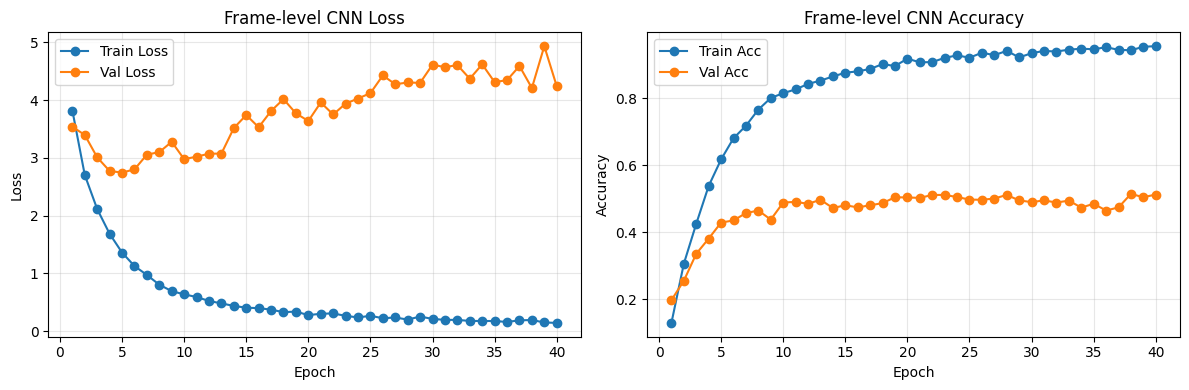

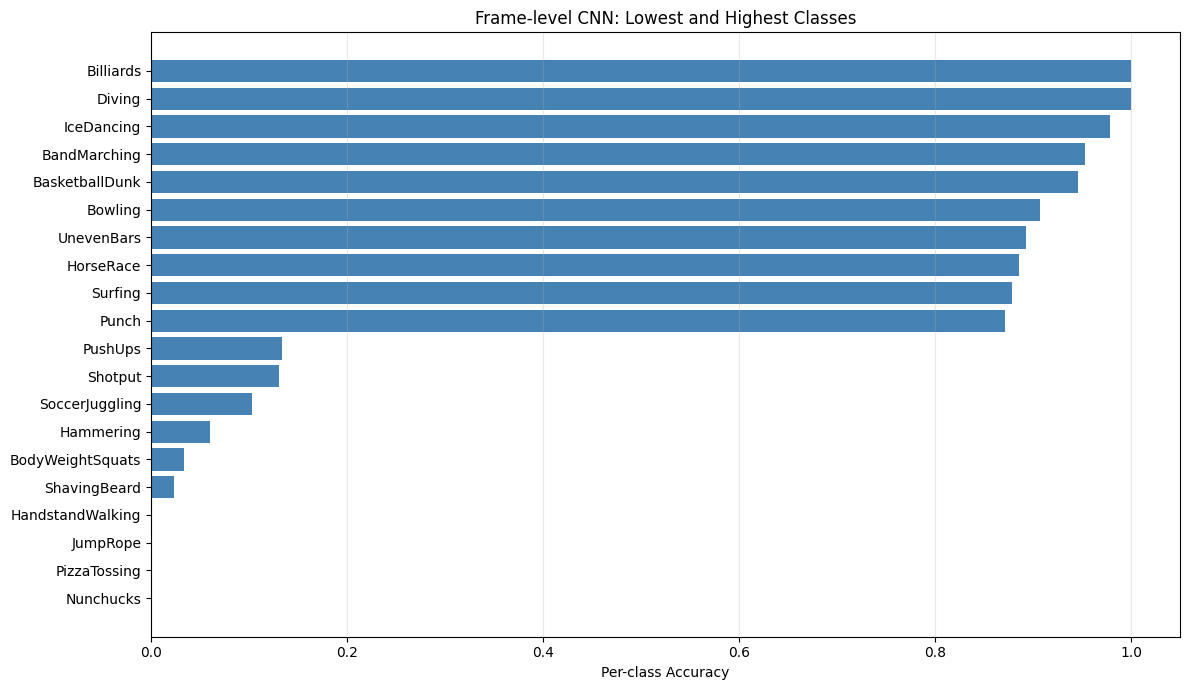

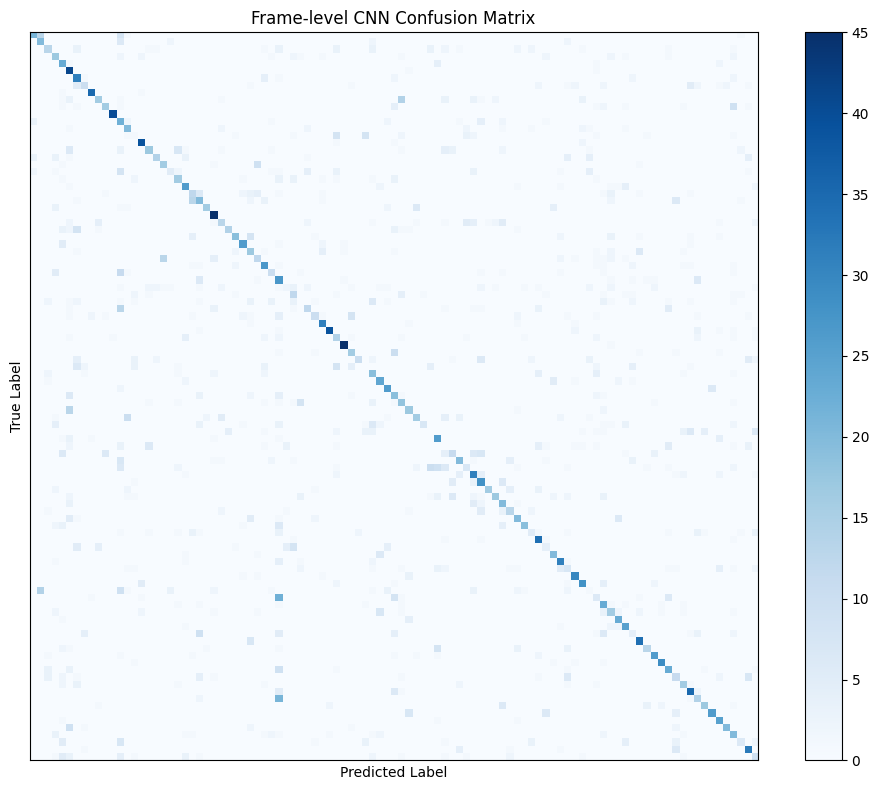

In [17]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_predictions, labels=np.arange(len(selected_classes)))

# Find the worst and best classes
valid_indices = np.where(~np.isnan(frame_eval_per_class_acc))[0]
summary_indices = valid_indices[np.argsort(frame_eval_per_class_acc[valid_indices])]
summary_indices = np.array(list(dict.fromkeys(
    np.concatenate([summary_indices[:10], summary_indices[-10:]]).tolist()
)))

print(f"{'Class':<30} {'Accuracy':>10}")
print("-" * 43)
for idx in summary_indices:
    print(f"{selected_classes[idx]:<30} {frame_eval_per_class_acc[idx]:>10.4f}")

# Training curve
epochs = range(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"],   marker="o", label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Frame-level CNN Loss"); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], marker="o", label="Train Acc")
plt.plot(epochs, history["val_acc"],   marker="o", label="Val Acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Frame-level CNN Accuracy"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Per-class accuracy
plot_classes = [selected_classes[i] for i in summary_indices]
plot_acc     = frame_eval_per_class_acc[summary_indices]
plt.figure(figsize=(12, max(6, len(plot_classes) * 0.35)))
plt.barh(plot_classes, plot_acc, color="steelblue")
plt.xlabel("Per-class Accuracy"); plt.title("Frame-level CNN: Lowest and Highest Classes")
plt.xlim(0, 1.05); plt.grid(axis="x", alpha=0.3); plt.tight_layout(); plt.show()

# Confusion Matrix Visualization
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Frame-level CNN Confusion Matrix"); plt.colorbar()
plt.xticks([]); plt.yticks([])
plt.xlabel("Predicted Label"); plt.ylabel("True Label")
plt.tight_layout(); plt.show()

In [18]:
# Frame-level CNN test results are saved to disk in Step 11.


In [19]:
# Step 12: C3D-like CNN
class C3DLikeCNN(nn.Module):
    def __init__(self, num_classes):
        super(C3DLikeCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv3d(in_channels=3, out_channels=32, kernel_size=(3,3,3), padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1,2,2)),

            nn.Conv3d(in_channels=32, out_channels=64, kernel_size=(3,3,3), padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(2,2,2)),

            nn.Conv3d(64, 128, kernel_size=(3,3,3), padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(2,2,2)),

            nn.Conv3d(128, 256, kernel_size=(3,3,3), padding=1),
            nn.BatchNorm3d(256),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool3d((1,1,1))
        )
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        x = self.classifier(x)
        return x

c3d_model = C3DLikeCNN(num_classes=NUM_SELECTED_CLASSES).to(device)

clips, labels, _, _ = next(iter(train_loader))
c3d_outputs = c3d_model(clips.to(device))
print(f"Input shape:  {clips.shape}")
print(f"Output shape: {c3d_outputs.shape}")
print(f"Device: {next(c3d_model.parameters()).device}")

Input shape:  torch.Size([16, 3, 8, 112, 112])
Output shape: torch.Size([16, 101])
Device: cuda:0


In [20]:
# Step 13: Load trained C3D-like CNN if available, otherwise train from scratch
import json

c3d_path         = OUT_DIR / "c3d_model.pth"
c3d_history_path = OUT_DIR / "c3d_history.json"

if c3d_path.exists():
    c3d_model.load_state_dict(torch.load(str(c3d_path), map_location=device))
    c3d_model.eval()
    print(f"C3D model loaded from {c3d_path}")
    if c3d_history_path.exists():
        with open(c3d_history_path) as f:
            c3d_history = json.load(f)
        print(f"History loaded from {c3d_history_path}")
    else:
        c3d_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
        print("No history file found — history will be empty")
else:
    print(f"No checkpoint at {c3d_path} — training from scratch...")
    c3d_criterion = nn.CrossEntropyLoss()
    c3d_optimizer = torch.optim.Adam(c3d_model.parameters(), lr=LEARNING_RATE)
    c3d_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(NUM_EPOCHS):
        # ── Train ──
        c3d_model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for clips, labels, _, _ in tqdm(train_loader, desc=f"C3D Epoch {epoch+1}/{NUM_EPOCHS} Train"):
            clips, labels = clips.to(device), labels.to(device)
            c3d_optimizer.zero_grad()
            c3d_outputs = c3d_model(clips)
            loss = c3d_criterion(c3d_outputs, labels)
            loss.backward()
            c3d_optimizer.step()
            train_loss    += loss.item() * labels.size(0)
            train_correct += (c3d_outputs.argmax(1) == labels).sum().item()
            train_total   += labels.size(0)

        # ── Val ──
        c3d_model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for clips, labels, _, _ in tqdm(val_loader, desc=f"C3D Epoch {epoch+1}/{NUM_EPOCHS} Val"):
                clips, labels = clips.to(device), labels.to(device)
                c3d_outputs = c3d_model(clips)
                loss = c3d_criterion(c3d_outputs, labels)
                val_loss    += loss.item() * labels.size(0)
                val_correct += (c3d_outputs.argmax(1) == labels).sum().item()
                val_total   += labels.size(0)

        t_loss = train_loss / train_total
        t_acc  = train_correct / train_total
        v_loss = val_loss / val_total
        v_acc  = val_correct / val_total

        c3d_history["train_loss"].append(t_loss)
        c3d_history["train_acc"].append(t_acc)
        c3d_history["val_loss"].append(v_loss)
        c3d_history["val_acc"].append(v_acc)

        print(f"C3D Epoch {epoch+1}/{NUM_EPOCHS} | "
              f"Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | "
              f"Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}")

    torch.save(c3d_model.state_dict(), str(c3d_path))
    with open(c3d_history_path, "w") as f:
        json.dump(c3d_history, f)
    print(f"C3D model saved to {c3d_path}")
    print(f"History saved to {c3d_history_path}")


C3D model loaded from outputs_40_epochs_with_augmented/c3d_model.pth
History loaded from outputs_40_epochs_with_augmented/c3d_history.json


C3D test results loaded from disk
C3D-like CNN Test Accuracy: 0.4512

C3D-like CNN Per-class Accuracy Summary:
Mean per-class accuracy: 0.4468
Minimum per-class accuracy: 0.0000
Maximum per-class accuracy: 1.0000
Class                            Accuracy
-------------------------------------------
Archery                            0.0000
JugglingBalls                      0.0000
HandstandWalking                   0.0000
PlayingDaf                         0.0000
Nunchucks                          0.0000
Hammering                          0.0000
TaiChi                             0.0000
PizzaTossing                       0.0303
PlayingCello                       0.0455
YoYo                               0.0833
ParallelBars                       0.8378
Punch                              0.8718
PlayingPiano                       0.8929
Billiards                          0.9000
Surfing                            0.9091
Bowling                            0.9302
IceDancing                   

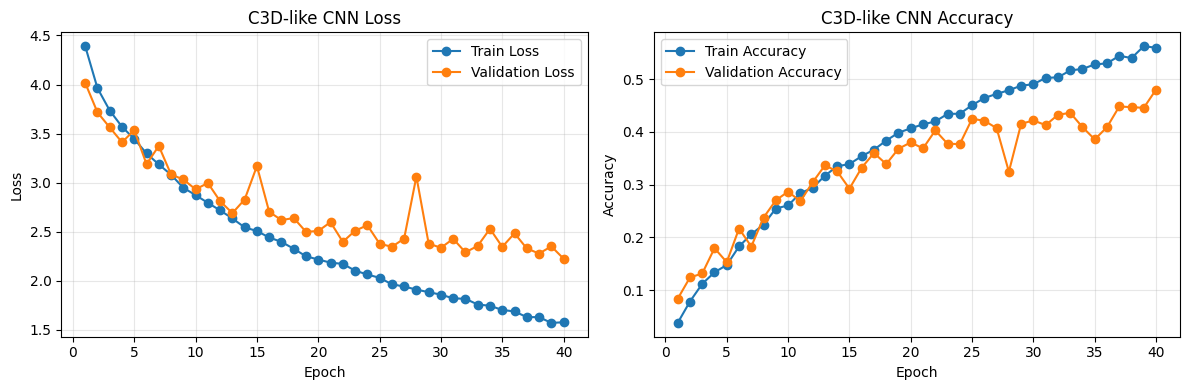

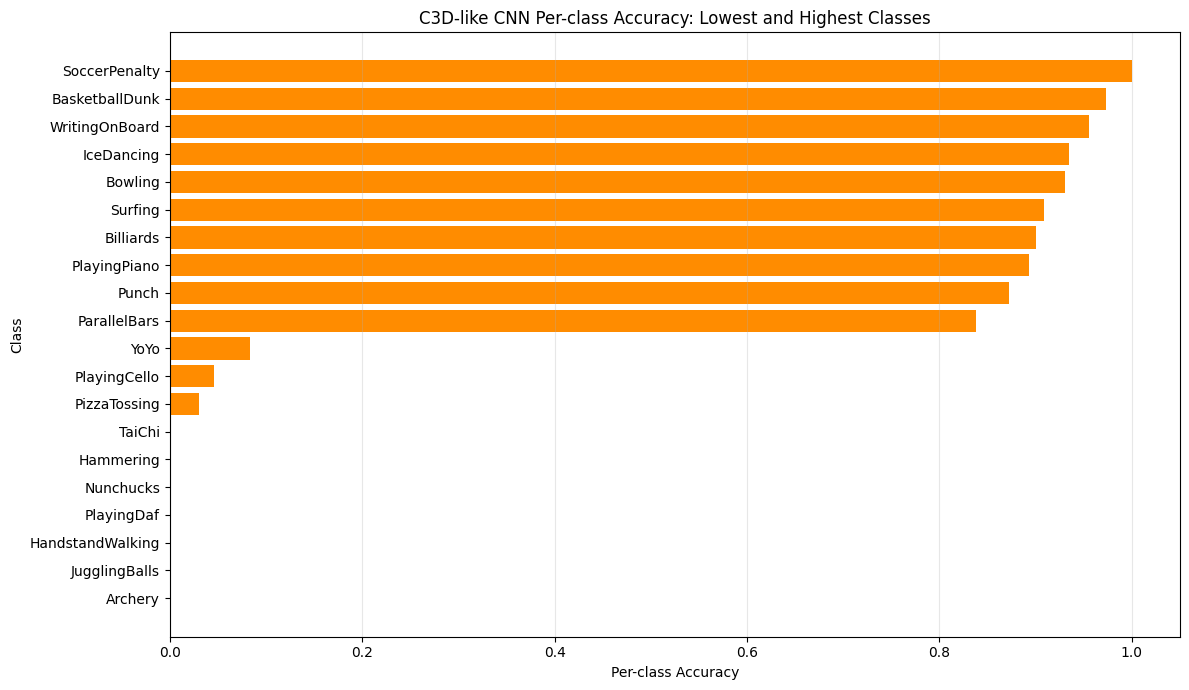

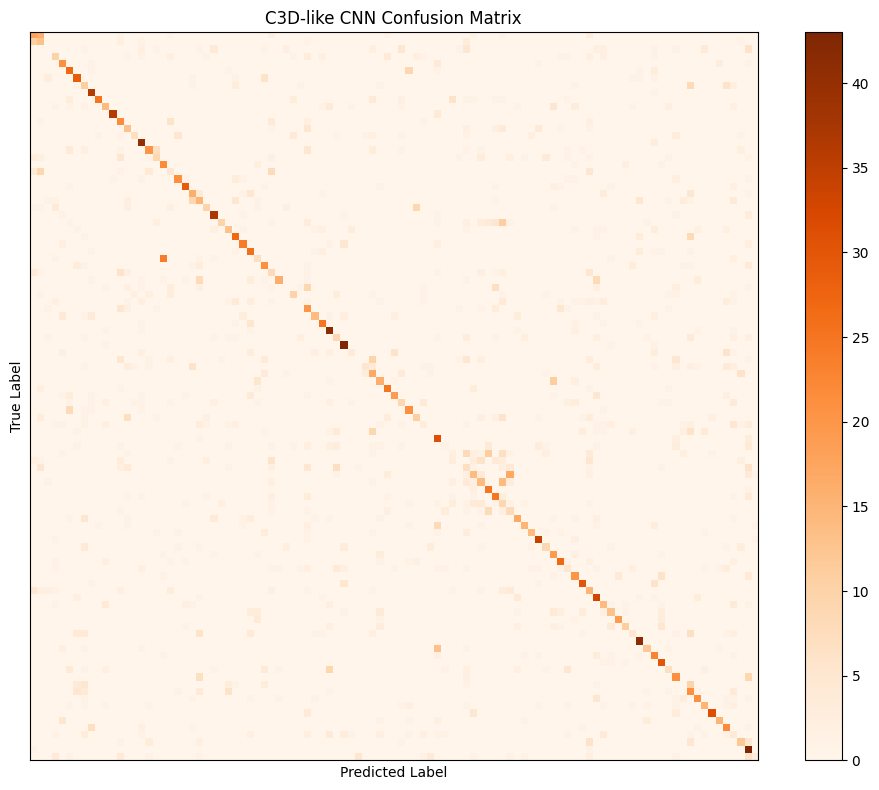

In [21]:
# Step 14: Evaluate C3D + Visualization
c3d_labels_path = OUT_DIR / "c3d_all_labels.npy"
c3d_preds_path  = OUT_DIR / "c3d_all_predictions.npy"
c3d_acc_path    = OUT_DIR / "c3d_per_class_acc.npy"

if c3d_labels_path.exists() and c3d_preds_path.exists() and c3d_acc_path.exists():
    c3d_all_labels      = np.load(c3d_labels_path)
    c3d_all_predictions = np.load(c3d_preds_path)
    c3d_per_class_acc   = np.load(c3d_acc_path)
    print("C3D test results loaded from disk")
else:
    c3d_model.eval()
    c3d_all_labels, c3d_all_predictions = [], []
    with torch.no_grad():
        for clips, labels, video_paths, class_names_batch in tqdm(test_loader, desc="Testing C3D-like CNN"):
            clips, labels = clips.to(device), labels.to(device)
            c3d_outputs = c3d_model(clips)
            c3d_predictions = c3d_outputs.argmax(dim=1)
            c3d_all_labels.extend(labels.cpu().numpy())
            c3d_all_predictions.extend(c3d_predictions.cpu().numpy())

    c3d_all_labels      = np.array(c3d_all_labels)
    c3d_all_predictions = np.array(c3d_all_predictions)

    c3d_per_class_acc = []
    for class_idx, class_name in enumerate(selected_classes):
        class_mask = c3d_all_labels == class_idx
        class_acc  = np.nan if class_mask.sum() == 0 else (c3d_all_predictions[class_mask] == c3d_all_labels[class_mask]).mean()
        c3d_per_class_acc.append(class_acc)
    c3d_per_class_acc = np.array(c3d_per_class_acc)

    np.save(c3d_labels_path, c3d_all_labels)
    np.save(c3d_preds_path,  c3d_all_predictions)
    np.save(c3d_acc_path,    c3d_per_class_acc)
    print("C3D test results saved to disk")

c3d_test_acc = (c3d_all_predictions == c3d_all_labels).mean()
print(f"C3D-like CNN Test Accuracy: {c3d_test_acc:.4f}")

c3d_cm = confusion_matrix(c3d_all_labels, c3d_all_predictions, labels=np.arange(len(selected_classes)))

valid_indices   = np.where(~np.isnan(c3d_per_class_acc))[0]
summary_indices = valid_indices[np.argsort(c3d_per_class_acc[valid_indices])]
summary_indices = np.array(list(dict.fromkeys(
    np.concatenate([summary_indices[:10], summary_indices[-10:]]).tolist()
)))

print(f"\nC3D-like CNN Per-class Accuracy Summary:")
print(f"Mean per-class accuracy: {np.nanmean(c3d_per_class_acc):.4f}")
print(f"Minimum per-class accuracy: {np.nanmin(c3d_per_class_acc):.4f}")
print(f"Maximum per-class accuracy: {np.nanmax(c3d_per_class_acc):.4f}")
print(f"{'Class':<30} {'Accuracy':>10}")
print("-" * 43)
for idx in summary_indices:
    print(f"{selected_classes[idx]:<30} {c3d_per_class_acc[idx]:>10.4f}")

# Training curve
c3d_epochs = range(1, len(c3d_history["train_loss"]) + 1)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(c3d_epochs, c3d_history["train_loss"], marker="o", label="Train Loss")
plt.plot(c3d_epochs, c3d_history["val_loss"],   marker="o", label="Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("C3D-like CNN Loss"); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(c3d_epochs, c3d_history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(c3d_epochs, c3d_history["val_acc"],   marker="o", label="Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("C3D-like CNN Accuracy"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Per-class accuracy
plot_classes = [selected_classes[i] for i in summary_indices]
plot_acc     = c3d_per_class_acc[summary_indices]
plt.figure(figsize=(12, max(6, len(plot_classes) * 0.35)))
plt.barh(plot_classes, plot_acc, color="darkorange")
plt.xlabel("Per-class Accuracy"); plt.ylabel("Class")
plt.title("C3D-like CNN Per-class Accuracy: Lowest and Highest Classes")
plt.xlim(0, 1.05); plt.grid(axis="x", alpha=0.3); plt.tight_layout(); plt.show()

# Confusion Matrix
plt.figure(figsize=(10, 8))
plt.imshow(c3d_cm, interpolation="nearest", cmap="Oranges")
plt.title("C3D-like CNN Confusion Matrix"); plt.colorbar()
plt.xticks([]); plt.yticks([])
plt.xlabel("Predicted Label"); plt.ylabel("True Label")
plt.tight_layout(); plt.show()


Overall Metrics
Metric                  Frame-CNN    C3D-like CNN
--------------------------------------------------
accuracy                   0.5009          0.4512
macro_precision            0.5182          0.4490
macro_recall               0.4990          0.4468
macro_f1                   0.4851          0.4250
weighted_precision         0.5217          0.4518
weighted_recall            0.5009          0.4512
weighted_f1                0.4876          0.4285

Per-class Accuracy Difference Summary
Classes: 101
Frame-CNN mean per-class accuracy: 0.4990
C3D-like CNN mean per-class accuracy: 0.4468
Mean difference: -0.0521
Class                             Frame-CNN    C3D-like CNN   Difference
---------------------------------------------------------------------------
TaiChi                               0.5714          0.0000      -0.5714
PlayingDaf                           0.4878          0.0000      -0.4878
SkyDiving                            0.8065          0.3548      -0.4516
W

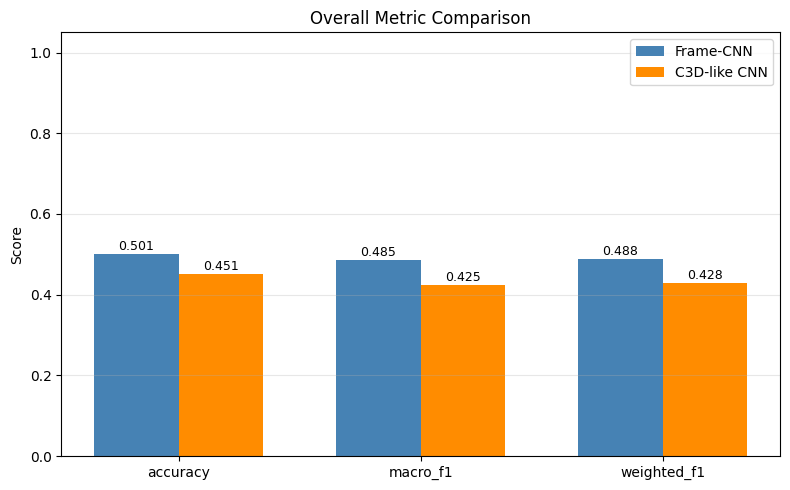

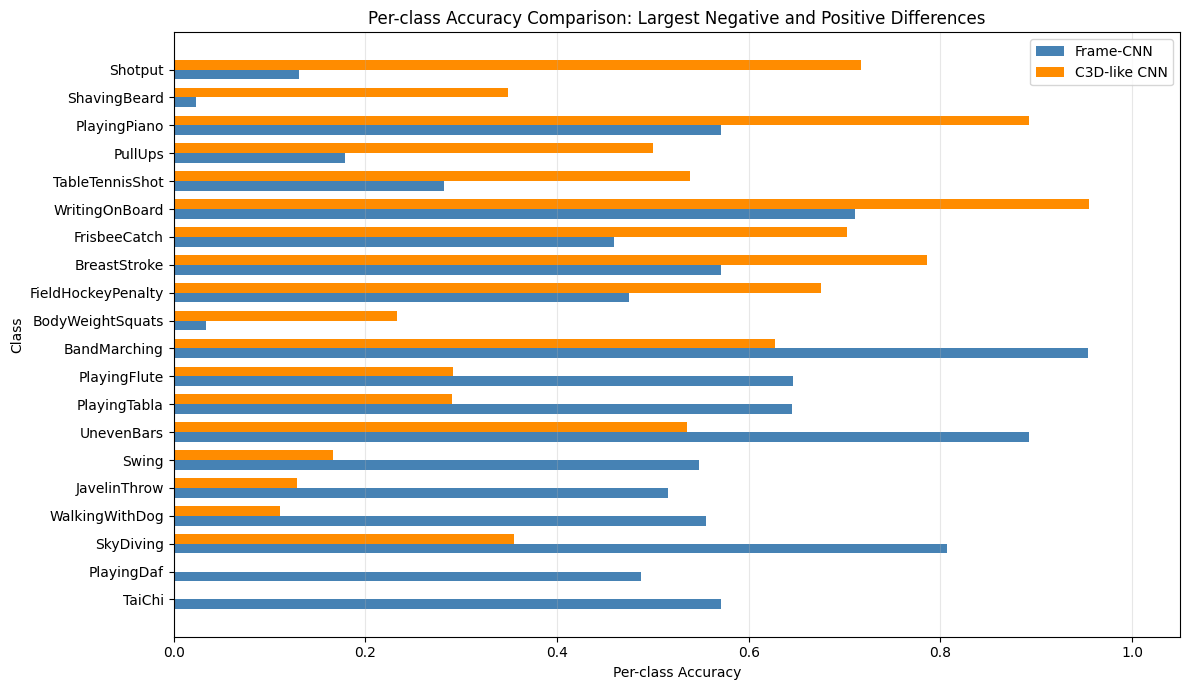

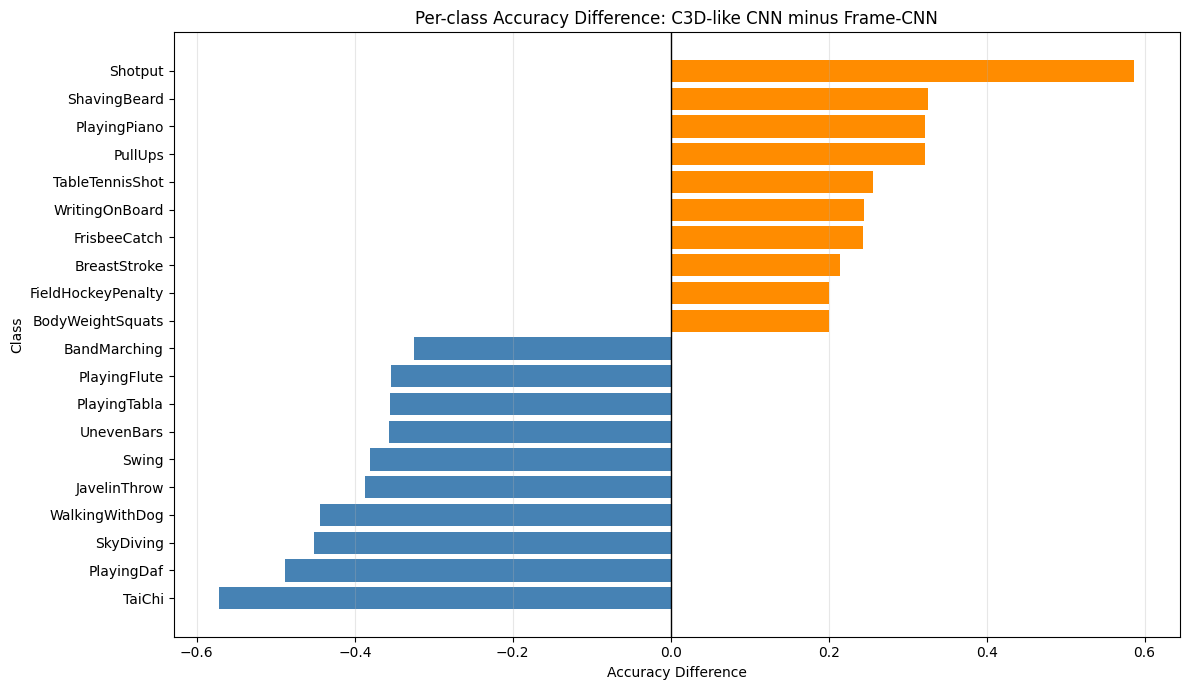

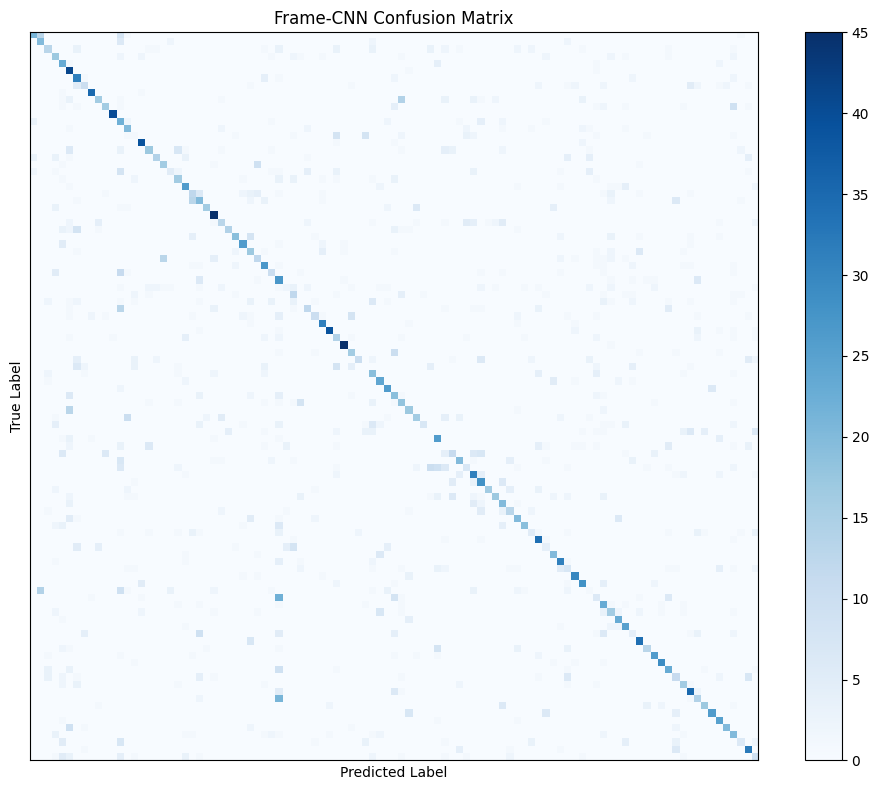

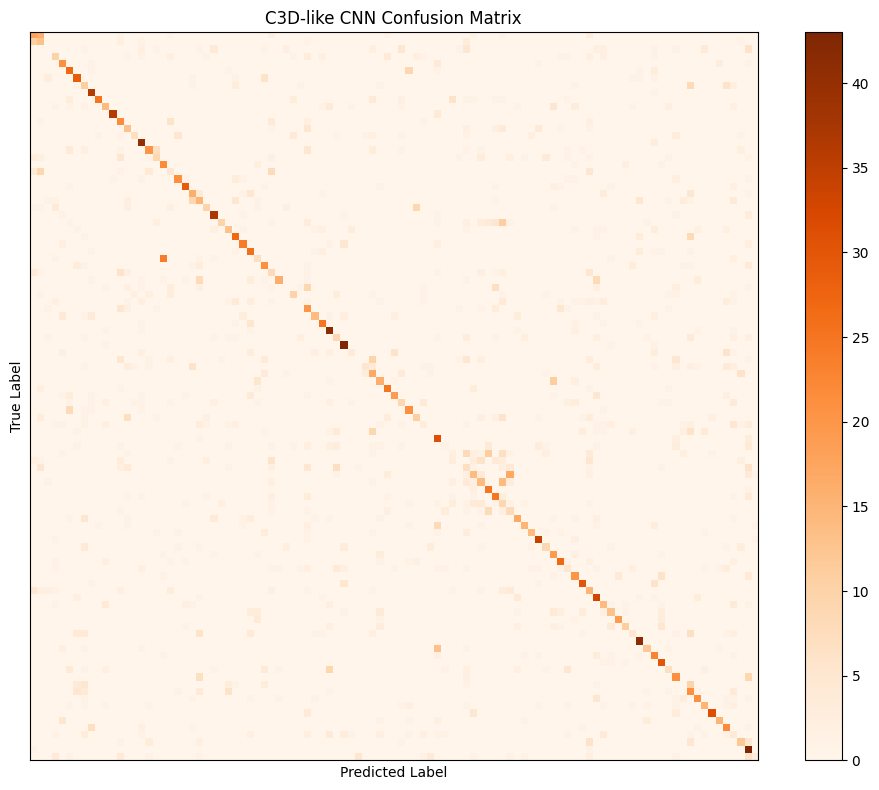

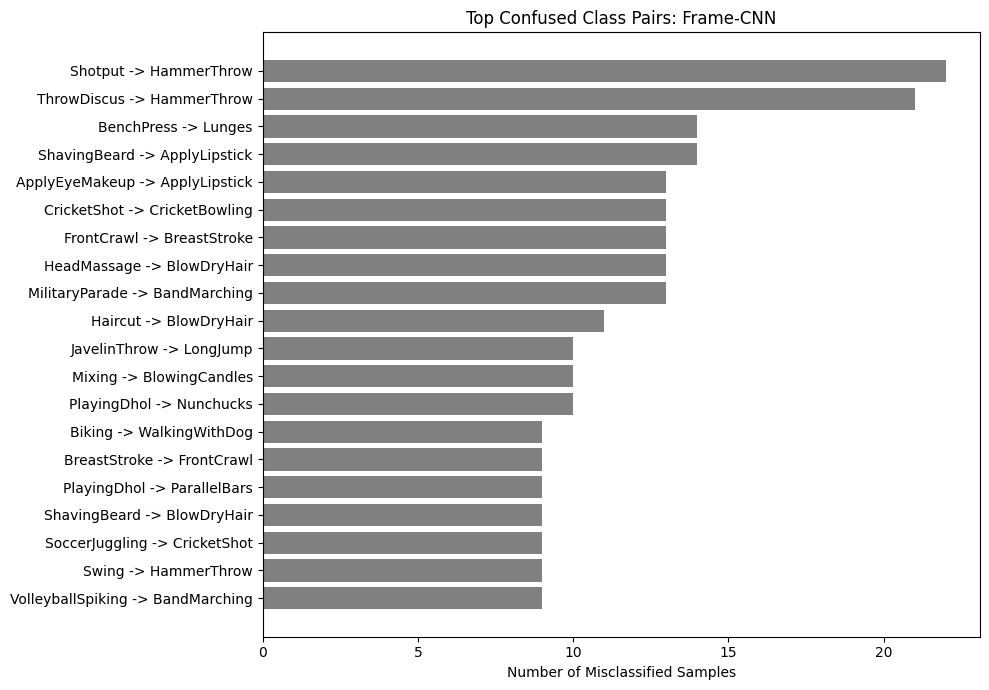

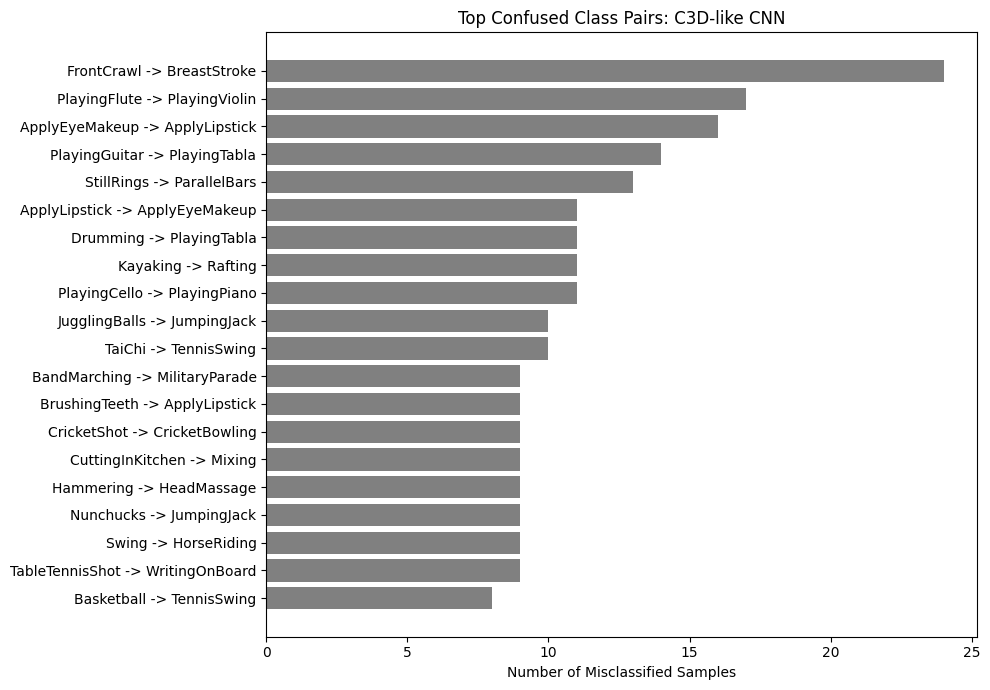

In [22]:
# Step 15: Compare the two models and visualize the results
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

frame_labels = all_labels
frame_preds = all_predictions

c3d_labels = c3d_all_labels
c3d_preds = c3d_all_predictions

num_classes = len(selected_classes)


def compute_summary_metrics(labels, preds):
    accuracy = accuracy_score(labels, preds)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        labels=np.arange(num_classes),
        average="macro",
        zero_division=0
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        labels=np.arange(num_classes),
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
    }


def compute_per_class_accuracy(labels, preds, num_classes):
    per_class_acc = []
    for class_idx in range(num_classes):
        class_mask = labels == class_idx
        class_acc = np.nan if class_mask.sum() == 0 else (preds[class_mask] == labels[class_mask]).mean()
        per_class_acc.append(class_acc)
    return np.array(per_class_acc)


def select_extreme_indices(values, top_k):
    valid_indices = np.where(~np.isnan(values))[0]
    sorted_indices = valid_indices[np.argsort(values[valid_indices])]
    candidate_indices = np.concatenate([sorted_indices[:top_k], sorted_indices[-top_k:]])
    return np.array(list(dict.fromkeys(candidate_indices.tolist())))


def get_top_confusions(cm_values, class_names, top_k=20):
    cm_without_diag = cm_values.copy()
    np.fill_diagonal(cm_without_diag, 0)

    pairs = []
    for true_idx in range(cm_without_diag.shape[0]):
        for pred_idx in range(cm_without_diag.shape[1]):
            count = cm_without_diag[true_idx, pred_idx]
            if count > 0:
                pairs.append((f"{class_names[true_idx]} -> {class_names[pred_idx]}", count))

    pairs = sorted(pairs, key=lambda x: x[1], reverse=True)
    return pairs[:top_k]


def plot_top_confusions(confusions, title):
    labels = [item[0] for item in confusions]
    counts = [item[1] for item in confusions]

    plt.figure(figsize=(10, 7))
    plt.barh(labels[::-1], counts[::-1], color="gray")
    plt.xlabel("Number of Misclassified Samples")
    plt.title(title)
    plt.tight_layout()
    plt.show()


frame_metrics = compute_summary_metrics(frame_labels, frame_preds)
c3d_metrics = compute_summary_metrics(c3d_labels, c3d_preds)

frame_per_class_acc = compute_per_class_accuracy(frame_labels, frame_preds, num_classes)
c3d_per_class_acc = compute_per_class_accuracy(c3d_labels, c3d_preds, num_classes)
acc_diff = c3d_per_class_acc - frame_per_class_acc
summary_indices = select_extreme_indices(acc_diff, top_k=min(10, num_classes))

print("Overall Metrics")
print(f"{'Metric':<20} {'Frame-CNN':>12} {'C3D-like CNN':>15}")
print("-" * 50)
for metric_name in frame_metrics.keys():
    print(f"{metric_name:<20} {frame_metrics[metric_name]:>12.4f} {c3d_metrics[metric_name]:>15.4f}")

print("\nPer-class Accuracy Difference Summary")
print(f"Classes: {num_classes}")
print(f"Frame-CNN mean per-class accuracy: {np.nanmean(frame_per_class_acc):.4f}")
print(f"C3D-like CNN mean per-class accuracy: {np.nanmean(c3d_per_class_acc):.4f}")
print(f"Mean difference: {np.nanmean(acc_diff):+.4f}")
print(f"{'Class':<30} {'Frame-CNN':>12} {'C3D-like CNN':>15} {'Difference':>12}")
print("-" * 75)
for idx in summary_indices:
    print(f"{selected_classes[idx]:<30} {frame_per_class_acc[idx]:>12.4f} {c3d_per_class_acc[idx]:>15.4f} {acc_diff[idx]:>12.4f}")

# Overall metrics visualization
metric_names = ["accuracy", "macro_f1", "weighted_f1"]
frame_values = [frame_metrics[m] for m in metric_names]
c3d_values = [c3d_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, frame_values, width, label="Frame-CNN", color="steelblue")
plt.bar(x + width / 2, c3d_values, width, label="C3D-like CNN", color="darkorange")
plt.xticks(x, metric_names)
plt.ylabel("Score")
plt.title("Overall Metric Comparison")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.3)
for i, value in enumerate(frame_values):
    plt.text(i - width / 2, value + 0.01, f"{value:.3f}", ha="center", fontsize=9)
for i, value in enumerate(c3d_values):
    plt.text(i + width / 2, value + 0.01, f"{value:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

# Per-class accuracy comparison on classes with largest negative/positive differences
plot_classes = [selected_classes[i] for i in summary_indices]
plot_frame_acc = frame_per_class_acc[summary_indices]
plot_c3d_acc = c3d_per_class_acc[summary_indices]
plot_diff = acc_diff[summary_indices]

x = np.arange(len(plot_classes))
width = 0.35

plt.figure(figsize=(12, max(6, len(plot_classes) * 0.35)))
plt.barh(x - width / 2, plot_frame_acc, width, label="Frame-CNN", color="steelblue")
plt.barh(x + width / 2, plot_c3d_acc, width, label="C3D-like CNN", color="darkorange")
plt.yticks(x, plot_classes)
plt.xlabel("Per-class Accuracy")
plt.ylabel("Class")
plt.title("Per-class Accuracy Comparison: Largest Negative and Positive Differences")
plt.xlim(0, 1.05)
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Per-class accuracy difference visualization
colors = ["darkorange" if diff >= 0 else "steelblue" for diff in plot_diff]

plt.figure(figsize=(12, max(6, len(plot_classes) * 0.35)))
plt.barh(plot_classes, plot_diff, color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Accuracy Difference")
plt.ylabel("Class")
plt.title("Per-class Accuracy Difference: C3D-like CNN minus Frame-CNN")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrices
frame_cm = confusion_matrix(frame_labels, frame_preds, labels=np.arange(num_classes))
c3d_cm = confusion_matrix(c3d_labels, c3d_preds, labels=np.arange(num_classes))

plt.figure(figsize=(10, 8))
plt.imshow(frame_cm, interpolation="nearest", cmap="Blues")
plt.title("Frame-CNN Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
plt.imshow(c3d_cm, interpolation="nearest", cmap="Oranges")
plt.title("C3D-like CNN Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

# Top confused class pairs
frame_top_confusions = get_top_confusions(frame_cm, selected_classes, top_k=20)
c3d_top_confusions = get_top_confusions(c3d_cm, selected_classes, top_k=20)

plot_top_confusions(frame_top_confusions, "Top Confused Class Pairs: Frame-CNN")
plot_top_confusions(c3d_top_confusions, "Top Confused Class Pairs: C3D-like CNN")